<a href="https://colab.research.google.com/github/rasyandazn/network-analysis-in-python/blob/main/Intro_to_Network_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1

## Creating Graph Object, its Nodes and Edges

In [1]:
import networkx as nx
G = nx.Graph()
G.add_nodes_from([1,2,3])
G.nodes()

NodeView((1, 2, 3))

In [2]:
# Add edge
G.add_edge(1,2)
G.edges()

EdgeView([(1, 2)])

## Labelling the nodes

In [3]:
G.nodes[1]['label'] = 'blue'
G.nodes(data=True)

NodeDataView({1: {'label': 'blue'}, 2: {}, 3: {}})

## Drawing the graph

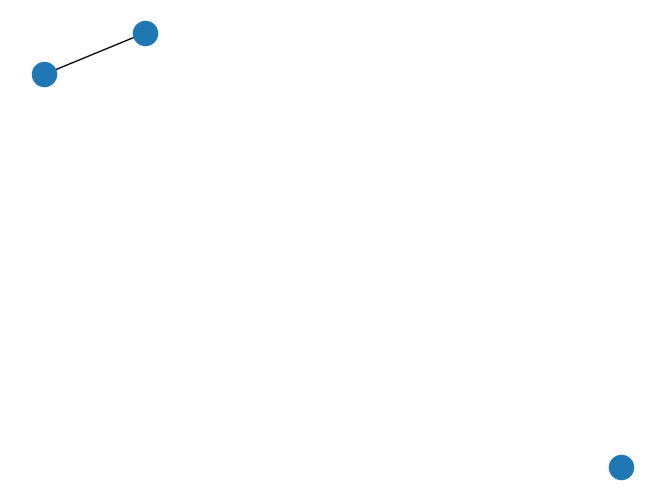

In [4]:
nx.draw(G)
import matplotlib.pyplot as plt
plt.show()

## Types of graph

In [5]:
# Undirected graphs. Ex: facebook social graph
G = nx.Graph()
type(G)

networkx.classes.graph.Graph

In [6]:
# Directed graphs. Ex: twitter social graph
D = nx.DiGraph()
type(D)

networkx.classes.digraph.DiGraph

In [7]:
# Multi-edge graphs. Ex: bank transfer records
M = nx.MultiGraph()
type(M)

networkx.classes.multigraph.MultiGraph

In [8]:
# Multi-edge directed graphs. Ex: flight availability (not focusing on a TO b nor b TO a. just: there IS a flight between a and b)
MD = nx.MultiDiGraph()
type(MD)

networkx.classes.multidigraph.MultiDiGraph

**Load some graphs for learning-purposes**

In [9]:
import pandas as pd
import networkx as nx

# URL dataset jaringan Twitter sederhana dari Stanford SNAP
url = "https://raw.githubusercontent.com/everestpipkin/tools-against-tracking/master/facebook_combined.txt"
# Atau menggunakan edge list dari github public

# Contoh membuat Directed Graph (DiGraph) dari edge list online:
# Format data: NodeFrom NodeTo
df = pd.read_csv("https://snap.stanford.edu/data/twitter_combined.txt.gz",
                 sep=" ",
                 header=None,
                 names=["source", "target"],
                 compression="gzip",
                 nrows=10000) # Ambil 10.000 baris pertama saja agar Colab tidak berat

# Convert pandas dataframe langsung jadi NetworkX DiGraph (mirip T di DataCamp)
T = nx.from_pandas_edgelist(df, source="source", target="target", create_using=nx.DiGraph())

print(f"Network 'T' berhasil dibuat! Type: {type(T)}")
print(f"Nodes: {T.number_of_nodes()}, Edges: {T.number_of_edges()}")

Network 'T' berhasil dibuat! Type: <class 'networkx.classes.digraph.DiGraph'>
Nodes: 428, Edges: 9994


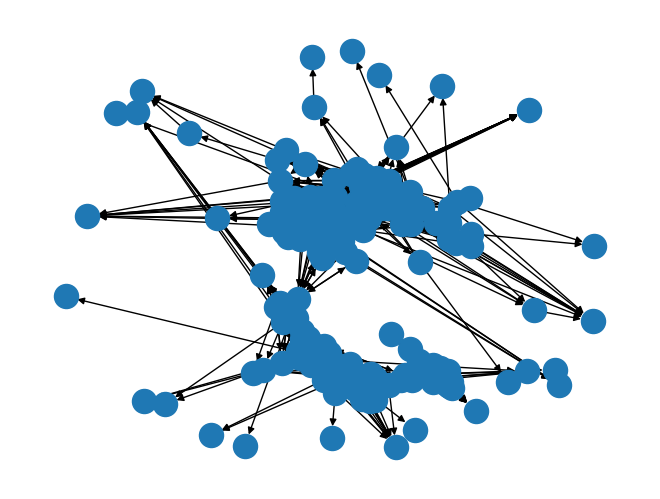

In [10]:
nx.draw(T)
plt.show()

In [11]:
K = nx.karate_club_graph()
print(f"Number of nodse: {K.number_of_nodes()}")
print(f"Number of edges: {K.number_of_edges()}")

Number of nodse: 34
Number of edges: 78


In [12]:
K.nodes()

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33))

In [13]:
K.edges(data=True)

EdgeDataView([(0, 1, {'weight': 4}), (0, 2, {'weight': 5}), (0, 3, {'weight': 3}), (0, 4, {'weight': 3}), (0, 5, {'weight': 3}), (0, 6, {'weight': 3}), (0, 7, {'weight': 2}), (0, 8, {'weight': 2}), (0, 10, {'weight': 2}), (0, 11, {'weight': 3}), (0, 12, {'weight': 1}), (0, 13, {'weight': 3}), (0, 17, {'weight': 2}), (0, 19, {'weight': 2}), (0, 21, {'weight': 2}), (0, 31, {'weight': 2}), (1, 2, {'weight': 6}), (1, 3, {'weight': 3}), (1, 7, {'weight': 4}), (1, 13, {'weight': 5}), (1, 17, {'weight': 1}), (1, 19, {'weight': 2}), (1, 21, {'weight': 2}), (1, 30, {'weight': 2}), (2, 3, {'weight': 3}), (2, 7, {'weight': 4}), (2, 8, {'weight': 5}), (2, 9, {'weight': 1}), (2, 13, {'weight': 3}), (2, 27, {'weight': 2}), (2, 28, {'weight': 2}), (2, 32, {'weight': 2}), (3, 7, {'weight': 3}), (3, 12, {'weight': 3}), (3, 13, {'weight': 3}), (4, 6, {'weight': 2}), (4, 10, {'weight': 3}), (5, 6, {'weight': 5}), (5, 10, {'weight': 3}), (5, 16, {'weight': 3}), (6, 16, {'weight': 3}), (8, 30, {'weight': 3

In [14]:
type(K)

networkx.classes.graph.Graph

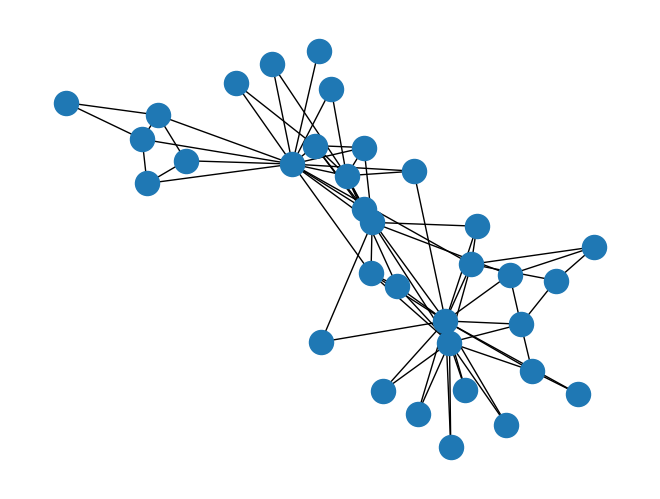

In [15]:
nx.draw(K)
plt.show()

Insight from loading some graphs: By default, 1 graph object must only has one type (either directed or undirected). If real-life scenario requires a graph where both types of edges exist, there are at least two alternatives:

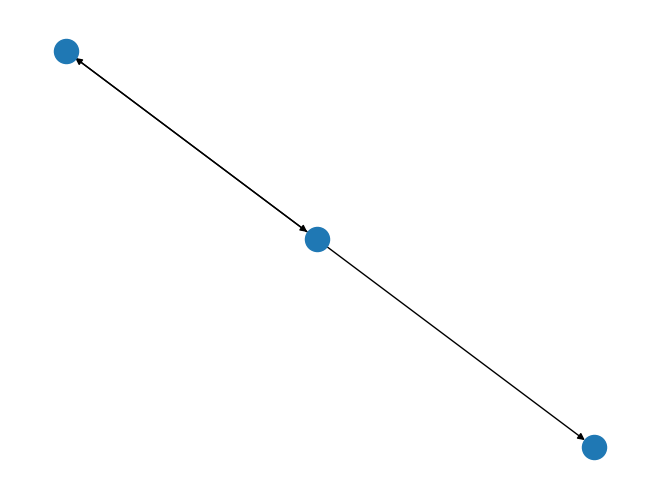

In [16]:
# 1. Change all to directed graph

# Use Directed Graph accomodate all kinds of relation
Ex1 = nx.DiGraph()

# Directed relations. Ex: Alice gives instructions to Bob
Ex1.add_edge("Alice" , "Bob", relation="instruction")

# Undirected relations (thus represented by two edges)
Ex1.add_edge("Alice", "Charlie", relation="colleague")
Ex1.add_edge("Charlie", "Alice", relation="colleague")

nx.draw(Ex1)
plt.show()

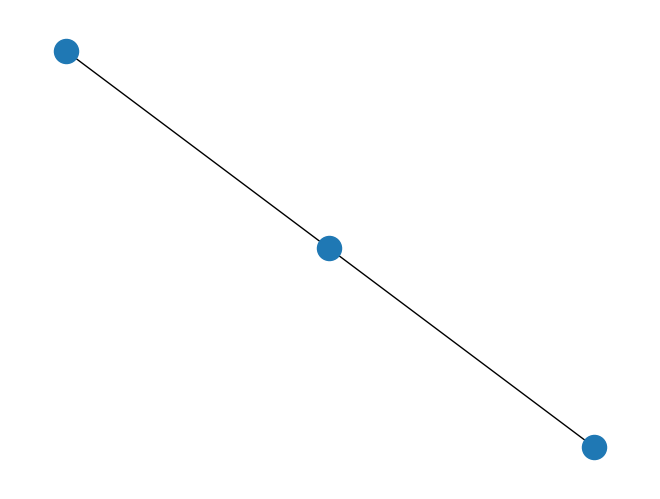

In [17]:
# 2. Use basic Undirected graph, then add the relations to the attribute dictionary
Ex2 = nx.Graph()

Ex2.add_edge("Alice", "Bob", is_directed=False, direction="Alice->Bob")
Ex2.add_edge("Alice", "Charlie", is_directed=True, direction="mutual")

nx.draw(Ex2)
plt.show()

Alternative 2 has its limitation: cause we defined its type as basic Undirected graph, while nx.draw() only draws the nodes and edges without its attributes, so we have to call the attributes with extra lines of codes, below:

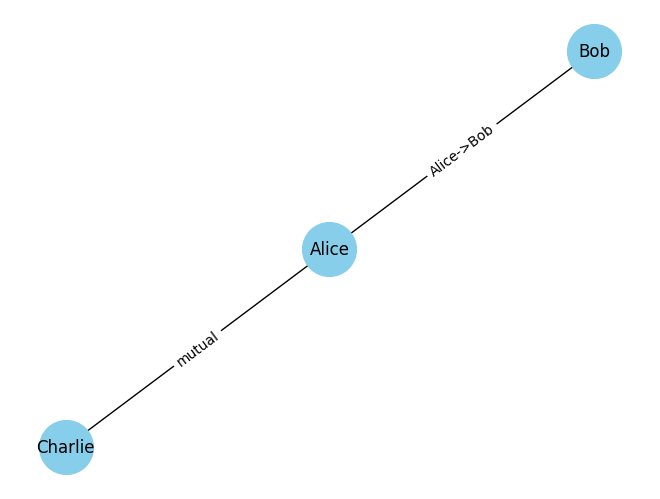

In [18]:
pos = nx.spring_layout(Ex2, seed=42)

# Draw nodes and its names
nx.draw(Ex2, pos, with_labels=True, node_color='skyblue', node_size=1500)

# Extracy attribute "direction" and show it on the edges
edge_labels = nx.get_edge_attributes(Ex2, 'direction')
nx.draw_networkx_edge_labels(Ex2, pos, edge_labels=edge_labels)

plt.show()

Between the two alternatives, alternative 1 is considered a better practice. Cause in alternative two, the attribute direction="..." is nothing more than a text string which isn't understood by the NetworkX math algorithm

## Weight on edges

In [73]:
# We'll use the T graph

# For example, we wanna Set the weight of edge between node 214328887, 34428380
T.edges[214328887, 34428380]['weight'] = 2

# Ex2: set the weight of every edge involving certain node (we take node 380580781)
for u, v, d in T.edges(data=True):
  if 380580781 in (u,v):
    d['weight'] = 1.1

## Visualizing graphs

### Arc plots

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 17.9 MB/s eta 0:00:00


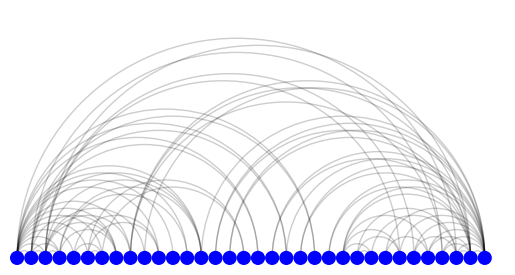

In [21]:
!pip install nxviz
import nxviz as nv

# Arc plots
ap = nv.arc(K)
plt.show()

In [22]:
# View metadata of the graph to understand what characteristics we can use in "sort by"
K.nodes[0]

{'club': 'Mr. Hi'}

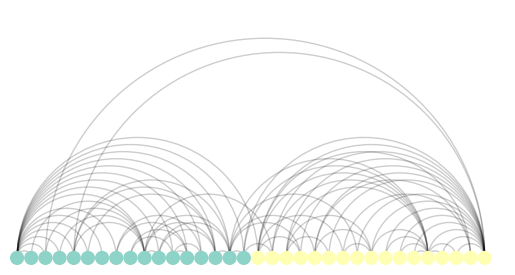

In [23]:
# Create a customized arc plot
a2 = nv.arc(K, sort_by='club', node_color_by='club')
plt.show()

### Matrix plot

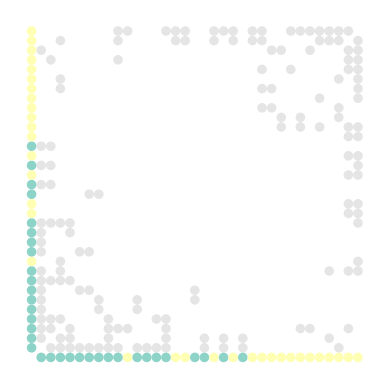

In [24]:
from nxviz import matrix
matrix(K,node_color_by='club')
plt.show()

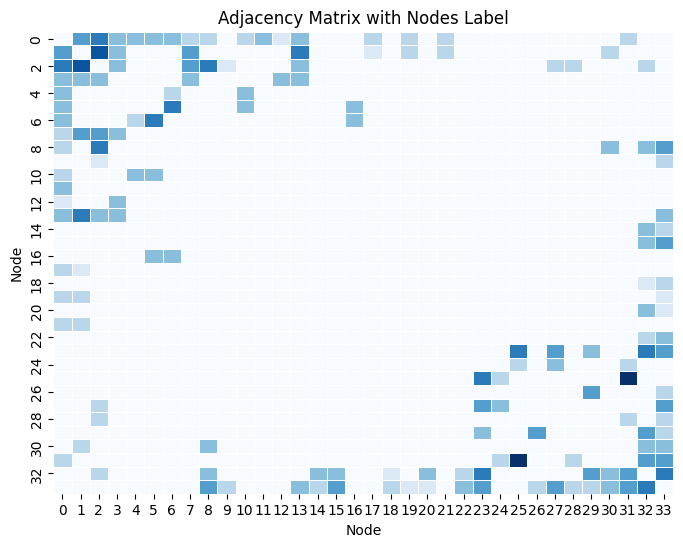

In [25]:
import seaborn as sns
df_adj = nx.to_pandas_adjacency(K)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_adj, cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Adjacency Matrix with Nodes Label")
plt.xlabel("Node")
plt.ylabel("Node")
plt.show()

Insight: the pattern between nx.matrix and heatmap using seaborn is different because here's the default of nx.matrix:
- Axis y: bottom (0) -> up
- Based on degree: nxviz tries to group nodes with similar "roles"/characteristics (for example: the most "popular" nodes i.e nodes with the highest numbers of degrees are put in close proximity

### Circos plot

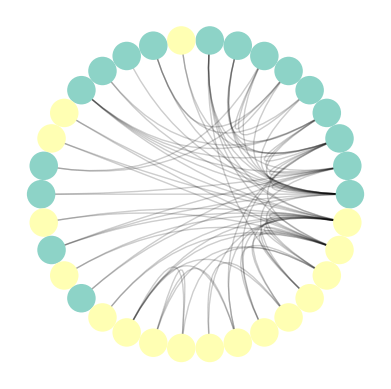

In [26]:
from nxviz import circos
c = circos(K, node_color_by='club')
plt.show()

# Module 2

## Degree centrality

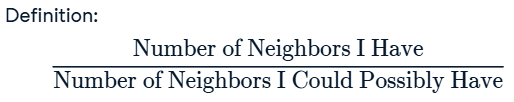

Note: "Number of neighbors I could possibily have" is basically the number of nodes in that graph, with 2 scenarios:
- If self-loop is allowed (ex: network mapping of all bike trips in a bike sharing system), then the "Number of neighbors I could possibly have" is every single node in the graph, including myself
- If self loop isn't allowed (ex: my twitter acc can't follow itself), then "Number of neighbors I could possibly have" is every other node in the graph2, excluding myself

In [27]:
# Neighbors of node 2
list(K.neighbors(2))

[0, 1, 3, 7, 8, 9, 13, 27, 28, 32]

In [28]:
# Degree centrality score for each nodes in graph K
nx.degree_centrality(K)

{0: 0.48484848484848486,
 1: 0.2727272727272727,
 2: 0.30303030303030304,
 3: 0.18181818181818182,
 4: 0.09090909090909091,
 5: 0.12121212121212122,
 6: 0.12121212121212122,
 7: 0.12121212121212122,
 8: 0.15151515151515152,
 9: 0.06060606060606061,
 10: 0.09090909090909091,
 11: 0.030303030303030304,
 12: 0.06060606060606061,
 13: 0.15151515151515152,
 14: 0.06060606060606061,
 15: 0.06060606060606061,
 16: 0.06060606060606061,
 17: 0.06060606060606061,
 18: 0.06060606060606061,
 19: 0.09090909090909091,
 20: 0.06060606060606061,
 21: 0.06060606060606061,
 22: 0.06060606060606061,
 23: 0.15151515151515152,
 24: 0.09090909090909091,
 25: 0.09090909090909091,
 26: 0.06060606060606061,
 27: 0.12121212121212122,
 28: 0.09090909090909091,
 29: 0.12121212121212122,
 30: 0.12121212121212122,
 31: 0.18181818181818182,
 32: 0.36363636363636365,
 33: 0.5151515151515151}

In [29]:
# Find all nodes in graph K that have m neighbors

def find_nodes_with_m_neighbors(G, m):
    nodes_with_m_neighbors = []
    for n in G.nodes():
        if len(list(G.neighbors(n))) == m:
            nodes_with_m_neighbors.append(n)
    return nodes_with_m_neighbors

# For example, we wanna find nodes that have 6 neighbors
find_nodes_with_m_neighbors(K, 6)

[3, 31]

In [30]:
# Compute the degree of every node
degrees = [len(list(K.neighbors(n))) for n in K.nodes()]

print(degrees)

[16, 9, 10, 6, 3, 4, 4, 4, 5, 2, 3, 1, 2, 5, 2, 2, 2, 2, 2, 3, 2, 2, 2, 5, 3, 3, 2, 4, 3, 4, 4, 6, 12, 17]


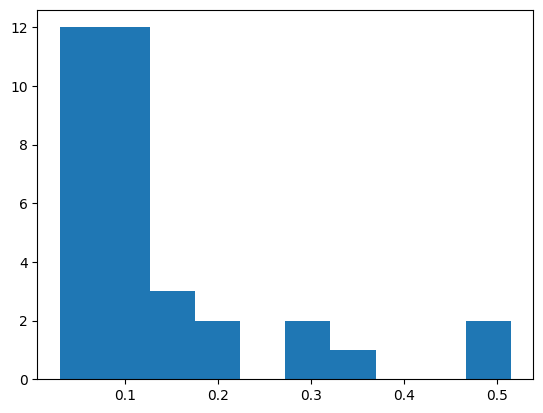

In [31]:
# Visualizing

# Histogram of degree centrality
deg_cent = nx.degree_centrality(K)
plt.hist(list(deg_cent.values()))
plt.show()

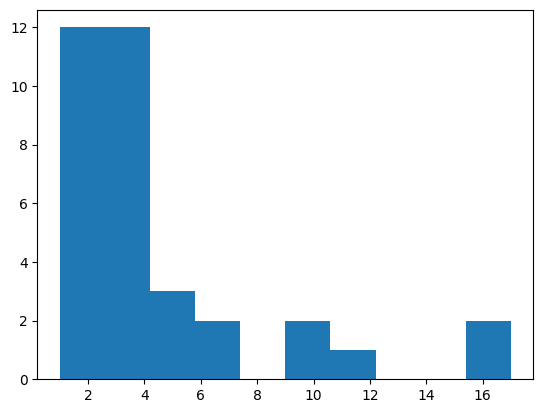

In [32]:
# Histogram of degree distribution
plt.hist(degrees)
plt.show()

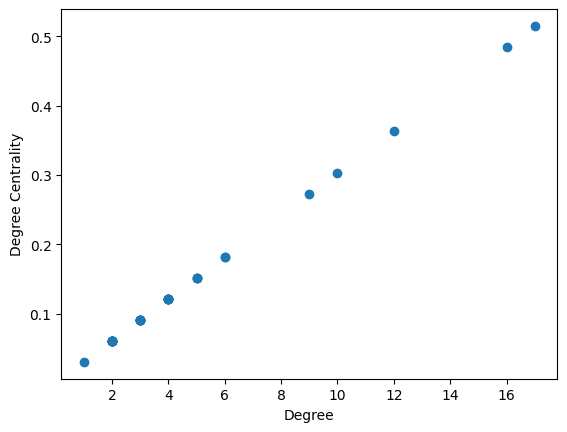

In [33]:
# Scatter plot between degree centrality and degree distribution
plt.scatter(x=degrees, y=list(deg_cent.values()))
plt.xlabel('Degree')
plt.ylabel('Degree Centrality')
plt.show()

## Path finding
Basically trying to answer two questions:
1. How do we find out whether there's a path between two nodes?
2. If there's a path, how do we find out what the shortest path is?

**Breadth-first search algorithm**

In [34]:
def path_exists(G, node1, node2):
  visited_nodes = set()

  # Initialize the queue of nodes to visit with the first node
  queue = [node1]

  # Iterate over the nodes in the queue
  for node in queue:

    # Get neighbors of the node
    neighbors = G.neighbors(node)

    # Check to see if the destination node is in the set of neighbors
    if node2 in neighbors:
      print('Path exists between nodes {0} and {1}'.format(node1, node2))
      return True

    else:
      # add current node to visited nodes
      visited_nodes.add(node)

      # Add neighbors of current node that have not yet been visited to queue
      queue.extend([n for n in neighbors if n not in visited_nodes])

  # When for looping stops bcs there's nothing left in the queue and node2 still not found:
  print(f'Path does not exist between nodes {node1} and {node2}')
  return False

## Betweenness centrality

If degree centrality measures a node's "popularity", betweenness centrality measures how crucial a node is as a bridge between two/more groups

**Definition**: A metric that measures how often a node acts as a bridge in every shortest path exists in the graph

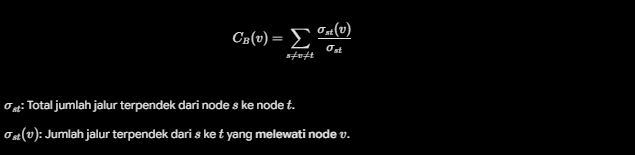

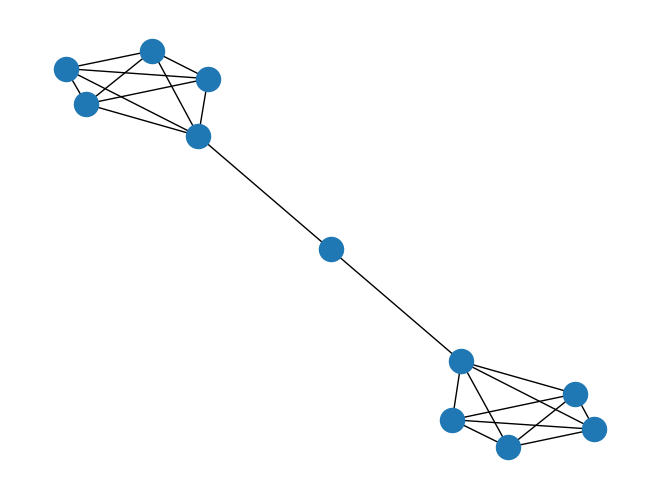

In [35]:
# Example, take a look at a barbell graph
bar = nx.barbell_graph(m1=5, m2=1)
nx.draw(bar)

In [36]:
nx.betweenness_centrality(bar)

{0: 0.0,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.5333333333333333,
 6: 0.5333333333333333,
 7: 0.0,
 8: 0.0,
 9: 0.0,
 10: 0.0,
 5: 0.5555555555555556}

Explanation:
- Eventho Node 5 has the lowest degree centra;ity (since it's only connected to other 2 nodes), but it has the highest betweenness centrality
- A node with a betweenness centrality of $0$ means it is not a critical path. If that node is removed from the network, the shortest paths between all other nodes will not be affected at all.

Text(0.5, 1.0, 'Degree Centrality vs Betweenness Centrality')

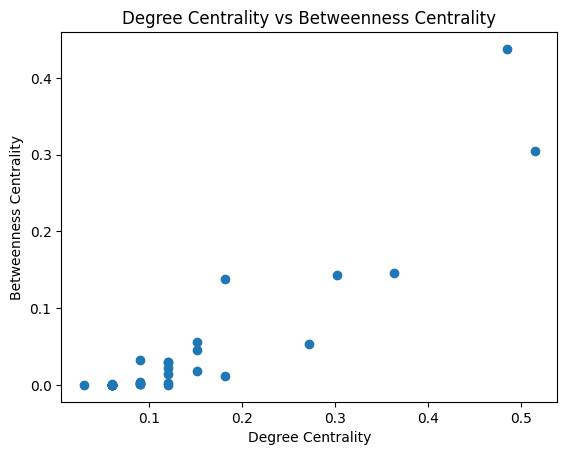

In [37]:
# Visualizing comparison between degree centrality and betweenness centrality
degree_centrality = nx.degree_centrality(K)
betweenness_centrality = nx.betweenness_centrality(K)

plt.scatter(x=list(degree_centrality.values()), y=list(betweenness_centrality.values()))
plt.xlabel('Degree Centrality')
plt.ylabel('Betweenness Centrality')
plt.title('Degree Centrality vs Betweenness Centrality')

In [38]:
# Finding node with the highest degree centrality
def find_nodes_with_highest_degree_centrality(G):
    degree_centrality = nx.degree_centrality(G)
    max_dc = max(list(degree_centrality.values()))

    nodes = set()

    # Iterate over the degree centrality dict
    for k, v in degree_centrality.items():
        # Check if the current value is the max degree centrality
        if v == max_dc:

            # Add the current node to the set of nodes
            nodes.add(k)
    return nodes

# Find the node(s) that has the highest degree centrality in K
print(find_nodes_with_highest_degree_centrality(K))

{33}


In [39]:
# Finding node with the highest betweenness centrality
def find_nodes_with_highest_betweenness_centrality(G):
    betweenness_centrality = nx.betweenness_centrality(G)
    max_bc = max(list(betweenness_centrality.values()))

    nodes = set()

    # Iterate over the betweenness centrality dict
    for k, v in betweenness_centrality.items():
        # Check if the current value is the max betweenness centrality
        if v == max_bc:

            # Add the current node to the set of nodes
            nodes.add(k)
    return nodes

# Find the node(s) that has the highest betweenness centrality in K
print(find_nodes_with_highest_betweenness_centrality(K))

{0}


# Module 3

## Triangle

In [40]:
from itertools import combinations

def is_in_triangle(G,n):
  for n1,n2 in combinations(list(G.neighbors(n)), 2):
    if G.has_edge(n1,n2):
      return True

  return False

Explanation: the function above is to check whether a node n is (at least) in one triangle. The n node is connected with n1 and n2 (because n1 and n2 is taken from list of G.neighbors(n)) -> then we want to check if that n1 and n2 is connected with each other. If yes, then n, n1, and n2 form a triangle

In [41]:
K.edges()

EdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16), (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33), (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32), (31, 33), (32, 33)])

In [42]:
is_in_triangle(K,5)

True

In [43]:
# From the function and example above, we already conclude that node 5 in graph K has (at least) one triangle relationship
# We're gonna take this further to see which nodes form the triangle relationship with node 5

def find_nodes_in_triangle(G,n):

  # Initialize a set consisting of the node n itself
  nodes = set([n])

  for n1,n2 in combinations(list(G.neighbors(n)), 2):
    if G.has_edge(n1,n2):
      nodes.add(n1)
      nodes.add(n2)

  return nodes

In [44]:
find_nodes_in_triangle(K,5)

{0, 5, 6, 10, 16}

In [45]:
# From the function above, we still can't see which three nodes form a triangle

def get_triangles_of_node(G, n):
    triangles = []

    for n1, n2 in combinations(G.neighbors(n), 2):
        if G.has_edge(n1, n2):
            # Specifically append with 3 nodes forming the triangle
            triangles.append((n, n1, n2))

    return triangles

In [46]:
get_triangles_of_node(K,5)

[(5, 0, 6), (5, 0, 10), (5, 6, 16)]

In [47]:
# Now we'll do the (kinda) opposite: we wanna count how mane nodes having (at least) one open triangle

def find_open_triangles(G,n):
  for n1,n2 in combinations(list(G.neighbors(n)), 2):
    if not G.has_edge(n1,n2):
      return True

  return False

num_open_triangles = 0
for n in K.nodes():
  if find_open_triangles(K,n):
    num_open_triangles += 1

print(num_open_triangles)

22


In [48]:
# The function above is to see how MANY NODEs having (at least) one open triangle
# Below we'll see each open triangle and how MANY TRIANGLEs

def get_open_triangles(G):
    open_triangles = []

    # Iterate over all nodes in G
    for n in G.nodes():
        # Check every combination of node n' neighbors
        for n1, n2 in combinations(G.neighbors(n), 2):
            # IF terms confirming whether it's an open triangle
            if not G.has_edge(n1, n2):
                # Save the open triangles with node n being the center
                open_triangles.append((n, n1, n2))

    return open_triangles

# Execute the function
all_open_triangles = get_open_triangles(K)

# 1. See which nodes form open triangle(s)
print("List of Open Triangles (Center, Neighbor1, Neighbor2):")
print(all_open_triangles)

# 2. Count the number of open triangle
print("\nTotal Open Triangles:", len(all_open_triangles))

List of Open Triangles (Center, Neighbor1, Neighbor2):
[(0, 1, 4), (0, 1, 5), (0, 1, 6), (0, 1, 8), (0, 1, 10), (0, 1, 11), (0, 1, 12), (0, 1, 31), (0, 2, 4), (0, 2, 5), (0, 2, 6), (0, 2, 10), (0, 2, 11), (0, 2, 12), (0, 2, 17), (0, 2, 19), (0, 2, 21), (0, 2, 31), (0, 3, 4), (0, 3, 5), (0, 3, 6), (0, 3, 8), (0, 3, 10), (0, 3, 11), (0, 3, 17), (0, 3, 19), (0, 3, 21), (0, 3, 31), (0, 4, 5), (0, 4, 7), (0, 4, 8), (0, 4, 11), (0, 4, 12), (0, 4, 13), (0, 4, 17), (0, 4, 19), (0, 4, 21), (0, 4, 31), (0, 5, 7), (0, 5, 8), (0, 5, 11), (0, 5, 12), (0, 5, 13), (0, 5, 17), (0, 5, 19), (0, 5, 21), (0, 5, 31), (0, 6, 7), (0, 6, 8), (0, 6, 10), (0, 6, 11), (0, 6, 12), (0, 6, 13), (0, 6, 17), (0, 6, 19), (0, 6, 21), (0, 6, 31), (0, 7, 8), (0, 7, 10), (0, 7, 11), (0, 7, 12), (0, 7, 13), (0, 7, 17), (0, 7, 19), (0, 7, 21), (0, 7, 31), (0, 8, 10), (0, 8, 11), (0, 8, 12), (0, 8, 13), (0, 8, 17), (0, 8, 19), (0, 8, 21), (0, 8, 31), (0, 10, 11), (0, 10, 12), (0, 10, 13), (0, 10, 17), (0, 10, 19), (0, 10, 21

## Maximal Cliques

In [49]:
 # Define a function to find all maximal cliques in graph G that are of size 'size'
 def maximal_cliques(G, size):
  mcs = []
  for clique in list(nx.find_cliques(G)):
    if len(clique) == size:
      mcs.append(clique)
  return mcs

maximal_cliques(K, 3)

[[0, 1, 17],
 [0, 1, 19],
 [0, 1, 21],
 [0, 4, 10],
 [0, 4, 6],
 [0, 5, 10],
 [0, 5, 6],
 [0, 8, 2],
 [0, 12, 3],
 [2, 32, 8],
 [5, 16, 6],
 [33, 32, 14],
 [33, 32, 15],
 [33, 32, 18],
 [33, 32, 20],
 [33, 32, 22],
 [33, 32, 31],
 [33, 26, 29],
 [33, 27, 23],
 [33, 28, 31],
 [24, 25, 31]]

In [50]:
list(nx.find_cliques(K))

[[0, 1, 17],
 [0, 1, 2, 3, 13],
 [0, 1, 2, 3, 7],
 [0, 1, 19],
 [0, 1, 21],
 [0, 4, 10],
 [0, 4, 6],
 [0, 5, 10],
 [0, 5, 6],
 [0, 8, 2],
 [0, 11],
 [0, 12, 3],
 [0, 31],
 [1, 30],
 [2, 32, 8],
 [2, 9],
 [2, 27],
 [2, 28],
 [5, 16, 6],
 [33, 32, 8, 30],
 [33, 32, 14],
 [33, 32, 15],
 [33, 32, 18],
 [33, 32, 20],
 [33, 32, 22],
 [33, 32, 23, 29],
 [33, 32, 31],
 [33, 9],
 [33, 13],
 [33, 19],
 [33, 26, 29],
 [33, 27, 23],
 [33, 28, 31],
 [24, 25, 31],
 [24, 27],
 [25, 23]]

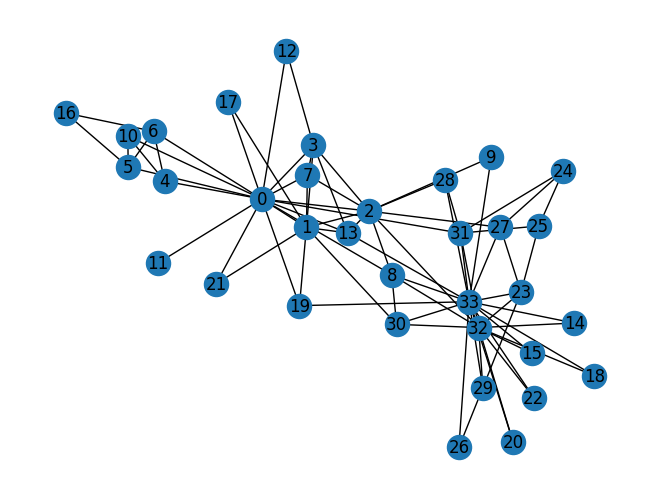

In [51]:
nx.draw(K, with_labels=True)

## Subgraphs

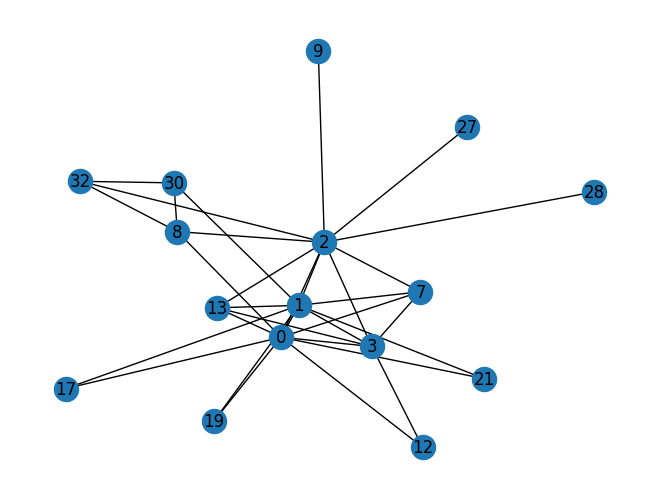

In [52]:
# Define a function that returns a subgraph of the graph G with only the 'nodes_of_interest' and their neighbors
def get_subgraph(G, nodes_of_interest):
  nodes_to_draw = []
  for node in nodes_of_interest:
    nodes_to_draw.append(node)

    for neighbor in G.neighbors(node):
      nodes_to_draw.append(neighbor)

  return G.subgraph(nodes_to_draw)

# Example:
K_subgraph = get_subgraph(K, [1,2,3])
nx.draw(K_subgraph, with_labels=True)
plt.show()

In [53]:
# Extract nodes that have a particular desired metadata property and their neighbors
def get_nodes_with_metadata(G, property, value):
  nodes = [n for n, d in G.nodes(data=True) if d.get(property) == value]

  # Create the set of nodes
  nodeset = set(nodes)

  # Iterate over nodes
  for n in nodes:

    # Compute the neighbors of n
    nbrs = G.neighbors(n)

    # Compute the union of nodeset and nbrs
    nodeset = nodeset.union(nbrs)

  # Create the subgraph involving desired nodes and their neighbors
  G_sub = G.subgraph(nodeset)

  return G_sub

In [54]:
K.nodes(data=True)

NodeDataView({0: {'club': 'Mr. Hi'}, 1: {'club': 'Mr. Hi'}, 2: {'club': 'Mr. Hi'}, 3: {'club': 'Mr. Hi'}, 4: {'club': 'Mr. Hi'}, 5: {'club': 'Mr. Hi'}, 6: {'club': 'Mr. Hi'}, 7: {'club': 'Mr. Hi'}, 8: {'club': 'Mr. Hi'}, 9: {'club': 'Officer'}, 10: {'club': 'Mr. Hi'}, 11: {'club': 'Mr. Hi'}, 12: {'club': 'Mr. Hi'}, 13: {'club': 'Mr. Hi'}, 14: {'club': 'Officer'}, 15: {'club': 'Officer'}, 16: {'club': 'Mr. Hi'}, 17: {'club': 'Mr. Hi'}, 18: {'club': 'Officer'}, 19: {'club': 'Mr. Hi'}, 20: {'club': 'Officer'}, 21: {'club': 'Mr. Hi'}, 22: {'club': 'Officer'}, 23: {'club': 'Officer'}, 24: {'club': 'Officer'}, 25: {'club': 'Officer'}, 26: {'club': 'Officer'}, 27: {'club': 'Officer'}, 28: {'club': 'Officer'}, 29: {'club': 'Officer'}, 30: {'club': 'Officer'}, 31: {'club': 'Officer'}, 32: {'club': 'Officer'}, 33: {'club': 'Officer'}})

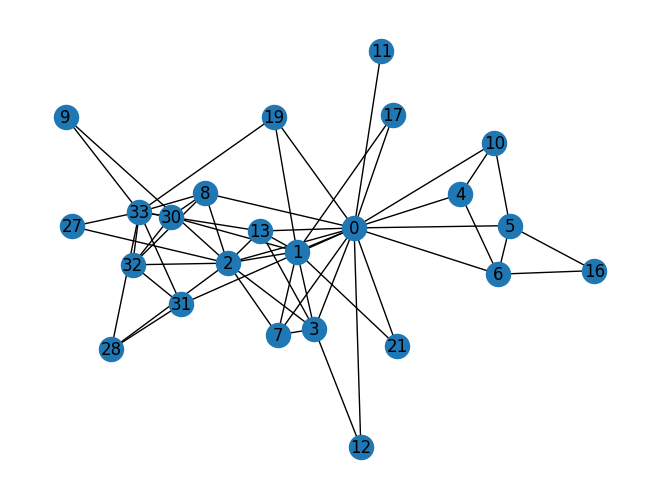

In [55]:
# Example
K_sub = get_nodes_with_metadata(K, 'club', 'Mr. Hi')
nx.draw(K_sub, with_labels=True)

In [56]:
K.nodes(data=True)

NodeDataView({0: {'club': 'Mr. Hi'}, 1: {'club': 'Mr. Hi'}, 2: {'club': 'Mr. Hi'}, 3: {'club': 'Mr. Hi'}, 4: {'club': 'Mr. Hi'}, 5: {'club': 'Mr. Hi'}, 6: {'club': 'Mr. Hi'}, 7: {'club': 'Mr. Hi'}, 8: {'club': 'Mr. Hi'}, 9: {'club': 'Officer'}, 10: {'club': 'Mr. Hi'}, 11: {'club': 'Mr. Hi'}, 12: {'club': 'Mr. Hi'}, 13: {'club': 'Mr. Hi'}, 14: {'club': 'Officer'}, 15: {'club': 'Officer'}, 16: {'club': 'Mr. Hi'}, 17: {'club': 'Mr. Hi'}, 18: {'club': 'Officer'}, 19: {'club': 'Mr. Hi'}, 20: {'club': 'Officer'}, 21: {'club': 'Mr. Hi'}, 22: {'club': 'Officer'}, 23: {'club': 'Officer'}, 24: {'club': 'Officer'}, 25: {'club': 'Officer'}, 26: {'club': 'Officer'}, 27: {'club': 'Officer'}, 28: {'club': 'Officer'}, 29: {'club': 'Officer'}, 30: {'club': 'Officer'}, 31: {'club': 'Officer'}, 32: {'club': 'Officer'}, 33: {'club': 'Officer'}})

# Modul 4

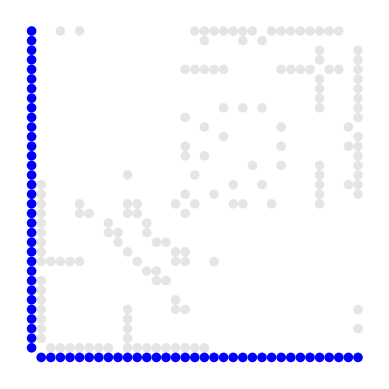

In [57]:
# Calculate the largest connected component
largest_ccs = max((K.subgraph(c) for c in nx.connected_components(K)), key=len)

# Create the customized Matrix plot: h
h = matrix(largest_ccs, group_by='club')

# Draw the Matrix plot to the screen
plt.show()

In [58]:
list(nx.connected_components(K))

[{0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33}]

Explanation: Graph $K$ turns out to have only 1 connected component (one large island) containing all 34 nodes (from node 0 to 33).
Since there is only 1 island, the largest island is simply the island itself (the entire graph $K$).

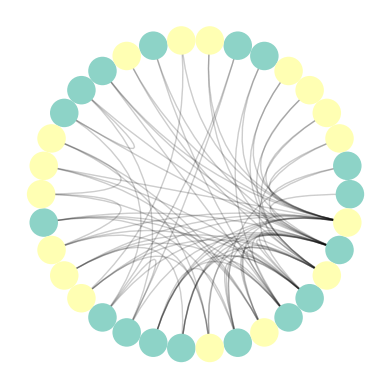

In [59]:
# Iterates over all nodes, including the metadata
for n, d in K.nodes(data=True):

  # Calculate the degree of each node
  K.nodes[n]['degree'] = nx.degree(K,n)

# Create the circos plot
c = circos(K, sort_by='degree', node_color_by='club')

# Draw the Circos plot to the screen
plt.show()

Explanation:
- Sorting Order: nxviz sorts nodes starting from 9 o'clock (180°) and arranges them clockwise around the circle.

- Node Placement:
  - Low-degree nodes (fewer connections) are placed near 9 to 12 o'clock.
  - High-degree nodes (hubs like node 0 and node 33) naturally land near 3 to 5 o'clock.

## Creating recommendation system (from a Karate Club Dataset)

### Finding the most popular node

In [60]:
# Compute the degree centralities of K
deg_cent = nx.degree_centrality(K)

# Compute the maximum degree centrality: max_dc
max_dc = max(list(deg_cent.values()))

# Find the user(s) that have collaborated the most: prolific_collaborators
prolific_collaborators = [n for n, dc in deg_cent.items() if dc == max_dc]

# Print the most prolific collaborator(s)
print(prolific_collaborators)

[33]


### Visualize most-dense community

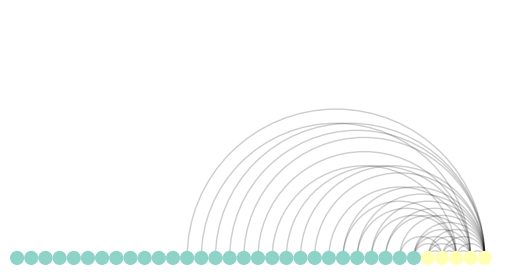

In [61]:
# Identify the largest maximal clique: largest_max_clique
largest_max_clique = set(sorted(nx.find_cliques(K), key=lambda x: len(x))[-1])

# Create a subgraph from the largest_max_clique: G_lmc
K_lmc = K.subgraph(largest_max_clique).copy()

# Go out 1 degree of separation (extract the neighbors of nodes in the largest max clique)
for node in list(K_lmc.nodes()):
    K_lmc.add_nodes_from(K.nodes())
    K_lmc.add_edges_from(zip([node]*len(list(K.neighbors(node))), K.neighbors(node)))

# Record each node's degree centrality score
for n in K_lmc.nodes():
    K_lmc.nodes[n]['degree centrality'] = nx.degree_centrality(K_lmc)[n]

# Label which nodes are part of the clique
for n in K_lmc.nodes():
  K_lmc.nodes[n]['is_clique'] = n in largest_max_clique

# Create the Arc plot: a
a = nv.arc(K_lmc, sort_by='degree centrality', node_color_by='is_clique')

# Draw the Arc plot to the screen
a
plt.show()

Explanation:

The Yellow nodes represent the "strongest" core circle, which plays a pivotal role in driving recommendations through two main mechanisms:

1. New Connection Recommendations (Triadic Closure / Open Triangles)
    - Mechanism: If Yellow1 is connected to TealA, and Yellow2 is also connected to TealA, then TealA possesses multiple mutual friends within the core circle.
    - Recommendation Logic: In link prediction algorithms, TealA has a significantly high probability of being recommended to the remaining members of the core circle (Yellow3, Yellow4, etc.), as their social environments already heavily overlap.

2. Bridge-Based Recommendations (Cross-Cluster / Brokerage)
    - Mechanism: If Teal1 (connected to Yellow1) and Teal2 (connected to Yellow2) are not directly connected to each other, the Yellow core group acts as a structural bridge or hub.
    - Recommendation Logic: The system can recommend Teal1 to Teal2 based on the premise: "You both orbit the same social or interest sphere (as you are both connected to members of the same core group)."

In [64]:
# Import necessary modules
from collections import defaultdict

# Initialize the defaultdict: recommended
recommended = defaultdict(int)

# Iterate over all the nodes in G
for n, d in K.nodes(data=True):

    # Iterate over all possible triangle relationship combinations
    for n1, n2 in combinations(list(K.neighbors(n)), 2):

        # Check whether n1 and n2 do not have an edge
        if not K.has_edge(n1, n2):

            # Increment recommended
            recommended[(n1,n2)] += 1

# Identify the top 10 pairs of users
all_counts = sorted(recommended.values())
top10_pairs = [(pair,count) for pair, count in recommended.items() if count > all_counts[-10]]
print(top10_pairs)


[((7, 13), 4), ((0, 33), 4), ((2, 33), 6)]


Explanation:
1. Dynamic Dictionary Keys (defaultdict)

    - Tuple as Key (n1, n2): In Python, any immutable object—including a tuple of two node IDs (n1, n2)—can serve as a dictionary key.
    - On-the-Fly Initialization: The advantage of initializing recommended = defaultdict(int) is that Python dynamically creates the key (n1, n2) the very first time it is accessed.
    - Automatic Default Value: Because it is set to int, Python automatically assigns a default starting value of 0 to any new key before executing the increment operation (+= 1). This eliminates the need for manual existence checks (e.g., if key not in dict).

2. Core Algorithm Step-by-Step Logic
Iterate Through All Nodes: The algorithm loops over every node n in the graph, treating node n as a potential mutual connector.

    - Generate Neighbor Combinations: For a given node n, it extracts all direct neighbors and generates every possible candidate pair (n1, n2) using combinations(neighbors, 2).
    - Check for Unconnected Pairs: For each pair, it verifies if a direct edge already exists using if not K.has_edge(n1, n2).
    - Increment Score: If n1 and n2 are not connected, it means node n acts as a mutual friend between them. The algorithm increments the pair's score (recommended[(n1, n2)] += 1).
    - Final Output Meaning: The resulting key-value pairs represent unconnected node pairs ranked by their total count of shared mutual friends.

In [78]:
from google.colab import drive
drive.mount('/content/drive')
!jupyter nbconvert --to html "/content/drive/My Drive/Colab Notebooks/Intro to Network Analysis.ipynb"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/Intro to Network Analysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 22 image(s).
[NbConvertApp] Writing 1582155 bytes to /content/drive/My Drive/Colab Notebooks/Intro to Network Analysis.html


In [79]:
from google.colab import files
files.download("/content/drive/My Drive/Colab Notebooks/Intro to Network Analysis.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>